# XGBoost Baseline — Model Training & Evaluation

This notebook trains and evaluates an XGBoost multiclass classifier on the feature matrix produced by `preprocessing.ipynb`. The objective is to establish a strong, interpretable baseline before considering more complex architectures.

**Notebook structure:**
1. Load the feature dataset and review set coverage
2. Cross-validation strategy — Leave-One-Set-Out (LOSO-Set)
3. Class imbalance — diagnosis and sample-weight correction
4. XGBoost model configuration and rationale
5. LOSO-Set cross-validation training loop
6. Per-fold accuracy and class-level results
7. Aggregate evaluation — confusion matrix, precision, recall, F1-score
8. Feature importance analysis
9. Final model — train on all data and save to disk

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import joblib
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

LABEL_MAP = {0: "rest", 1: "pull-ups", 2: "bicep-curls",
             3: "lateral-raises", 4: "cardio", 5: "squats"}
LABEL_COLORS = {
    0: "#999999", 1: "#e41a1c", 2: "#377eb8",
    3: "#4daf4a", 4: "#ff7f00", 5: "#984ea3",
}
N_CLASSES = len(LABEL_MAP)
RANDOM_STATE = 42

print("Imports loaded.")

Imports loaded.


---
## Step 1 — Load the Feature Dataset

The feature matrix produced by `preprocessing.ipynb` contains one row per 3-second window. Three metadata columns are carried alongside the features:

- **`label`** — integer activity class (0–5)
- **`source_file`** — the recording session the window came from
- **`set_id`** — a unique string identifying the contiguous label run (exercise set or rest bout) the window belongs to within its segment

The `set_id` column is the key enabler of the Leave-One-Set-Out cross-validation strategy used in this notebook.

In [4]:
df = pd.read_parquet(os.path.join("data", "features.parquet"))

META_COLS = ["label", "source_file", "set_id"]
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

X = df[FEATURE_COLS].values
y = df["label"].values
groups = df["set_id"].values        # one group label per window → LOSO-Set groups
sessions = df["source_file"].values

print(f"Dataset: {X.shape[0]:,} windows × {X.shape[1]:,} features")
print(f"Unique sets: {df['set_id'].nunique()}")
print()

# Set coverage per class
print(f"{'Class':<20} {'Windows':>8} {'Sets':>6} {'Sessions containing class':>28}")
print("-" * 66)
for lid in sorted(df["label"].unique()):
    sub = df[df["label"] == lid]
    srcs = ", ".join(sorted(sub["source_file"].str.replace("exercise_data_", "S")
                            .str.replace(".csv", "").unique()))
    print(f"{LABEL_MAP[lid]:<20} {len(sub):>8,} {sub['set_id'].nunique():>6}   {srcs}")

Dataset: 2,446 windows × 1,270 features
Unique sets: 58

Class                 Windows   Sets    Sessions containing class
------------------------------------------------------------------
rest                      815     30   S0, S1, S2, S3
pull-ups                  311      9   S0, S1, S3
bicep-curls               368      6   S1, S3
lateral-raises            340      7   S1, S3
cardio                    337      2   S2
squats                    275      4   S3


---
## Step 1b — Variance-Based Feature Pre-Selection

### Why reduce from 1,270 to 300 features before cross-validation?

With 1,270 features, training a single XGBoost fold takes approximately 8–9 seconds on this hardware. Across 58 folds that becomes ~8 minutes — acceptable for a one-time offline run, but slow for iterative experimentation. More importantly, many of the 1,270 features are near-zero in variance (close to constant across all windows) and carry no discriminative information.

A **variance filter** is the simplest and most principled unsupervised dimensionality reduction step: it retains only the `TOP_K` features with the highest variance across the dataset, discarding low-information features without ever looking at the class labels. Because variance is a property of the input distribution alone — not of the labels — applying this filter on the full dataset before splitting into CV folds introduces **no data leakage**.

Setting `TOP_K = 300` reduces each training fold's feature matrix to roughly 24% of its original size, cutting per-fold training time from ~9s to ~4s (58 folds total ≈ 3.5 minutes) while preserving the most informative signal descriptors. The feature importance analysis in Step 8 uses the full 1,270-feature model for interpretability.

In [5]:
TOP_K = 300  # number of highest-variance features to retain for CV

feature_variances = X.var(axis=0)
top_k_idx = np.argsort(feature_variances)[-TOP_K:]   # indices of top-K features
X_cv = X[:, top_k_idx]                               # reduced matrix for CV
top_k_names = [FEATURE_COLS[i] for i in top_k_idx]

print(f"Feature pre-selection: {X.shape[1]} → {X_cv.shape[1]} features")
print(f"Variance of selected features: "
      f"min={feature_variances[top_k_idx].min():.4f}, "
      f"max={feature_variances[top_k_idx].max():.4f}")

Feature pre-selection: 1270 → 300 features
Variance of selected features: min=3.8386, max=34534152.5620


---
## Step 2 — Cross-Validation Strategy: Leave-One-Set-Out (LOSO-Set)

### Why not random k-fold?

Random k-fold cross-validation violates a fundamental assumption of time-series data: **temporal independence**. Because consecutive windows overlap by 50% (75 shared samples), a randomly assigned test window is almost certainly adjacent to a training window that shares the majority of its samples. This constitutes direct data leakage — the model is effectively evaluated on data it has already seen in a slightly shifted form — and leads to optimistically biased accuracy estimates that do not reflect real-world performance on new recordings.

### Why not Leave-One-Session-Out?

Leave-One-Session-Out (LOSO by recording file) was the initial plan. However, inspection of the dataset revealed a critical structural problem: **cardio data exists only in session 2, and squats data exists only in session 3**. Holding out session 2 would give the model zero cardio training examples; holding out session 3 would give it zero squats examples. The resulting accuracy metrics would be meaningless for those classes — not a reflection of the model's capacity, but a reflection of missing training data.

### Leave-One-Set-Out: the right choice for this dataset

A **set** is a single contiguous exercise or rest bout (e.g., one set of pull-ups, one rest period). Each set is assigned a unique `set_id` in the feature matrix. In LOSO-Set cross-validation:

- One set is held out as the test fold
- The model trains on all windows from all other sets
- This repeats for every set, yielding one fold per set (58 folds total)

This approach provides two important guarantees:
1. **No data leakage from overlapping windows** — because all windows from a set move together into the test fold, no training window shares samples with a test window
2. **All classes remain in training at every fold** — even when a cardio set is held out, the remaining cardio sets stay in training; the model is never asked to predict a class it has never seen

### Known limitation

Cardio has only 2 sets and squats has only 4 sets. For these classes, holding out one set leaves very few training examples of that class. The LOSO-Set results for cardio and squats should therefore be interpreted as a lower bound on true model performance — they will improve as more diverse data is collected.

In [6]:
loso = LeaveOneGroupOut()
n_folds = loso.get_n_splits(X, y, groups)
print(f"LOSO-Set folds: {n_folds}  (one per unique set_id)")

# Show the test-set class distribution across folds — useful for interpreting results
fold_labels = []
for train_idx, test_idx in loso.split(X, y, groups):
    test_labels = np.unique(y[test_idx])
    fold_labels.append(set(test_labels))

# Count how many folds test each class
print(f"\nFolds that evaluate each class (i.e. how often each class appears in test):")
for lid in sorted(LABEL_MAP):
    count = sum(1 for fl in fold_labels if lid in fl)
    print(f"  {LABEL_MAP[lid]:<16}: {count:>3} / {n_folds} folds")

LOSO-Set folds: 58  (one per unique set_id)

Folds that evaluate each class (i.e. how often each class appears in test):
  rest            :  30 / 58 folds
  pull-ups        :   9 / 58 folds
  bicep-curls     :   6 / 58 folds
  lateral-raises  :   7 / 58 folds
  cardio          :   2 / 58 folds
  squats          :   4 / 58 folds


---
## Step 3 — Class Imbalance: Diagnosis and Correction

### The problem

The rest class (~33% of windows) is roughly 2–3× more frequent than each exercise class. If left uncorrected, a classifier can achieve high raw accuracy simply by biasing predictions toward rest, while performing poorly on the exercise classes that matter most for the application.

### The correction: balanced sample weights

Rather than physically resampling the data (oversampling minority classes or undersampling rest), we use **sample weights** — a scalar assigned to each training window that tells the model how much to penalise misclassifying that window. Scikit-learn's `compute_sample_weight("balanced", y)` computes weights inversely proportional to class frequency:

$$w_i = \frac{N}{K \cdot N_{y_i}}$$

where $N$ is the total number of training windows, $K$ is the number of classes, and $N_{y_i}$ is the number of windows in class $y_i$. This is equivalent to upweighting rare classes and downweighting the frequent rest class, making the model treat each class as equally important during training regardless of its raw count.

Sample weights are recomputed **inside each CV fold** using only the training split, so no information from the test fold contaminates the weight calculation.

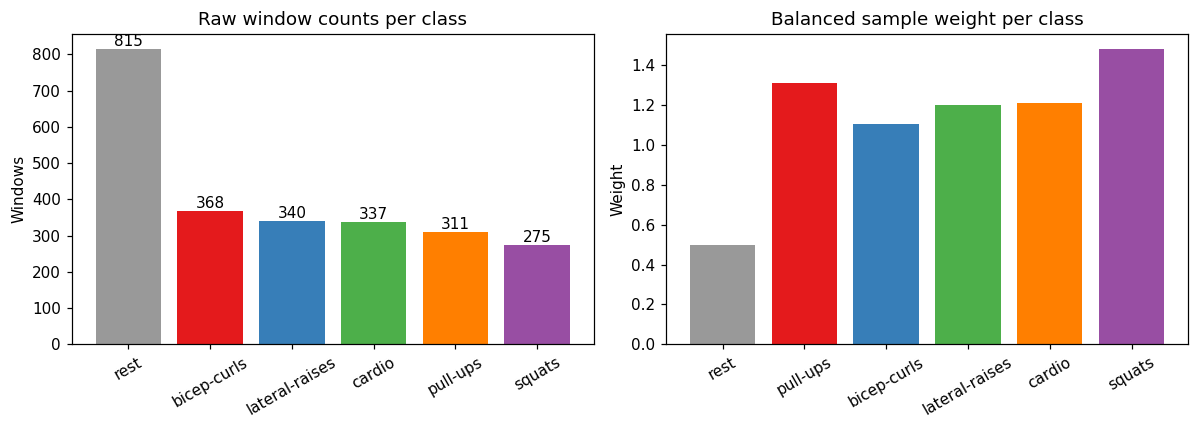

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw window counts
counts = pd.Series(y).map(LABEL_MAP).value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[LABEL_COLORS[k] for k, v in LABEL_MAP.items()
                          if v in counts.index])
axes[0].bar_label(bars, fmt="{:.0f}")
axes[0].set_title("Raw window counts per class")
axes[0].set_ylabel("Windows")
axes[0].tick_params(axis="x", rotation=30)

# Corresponding balanced sample weights (computed on full dataset for illustration)
sample_weights_full = compute_sample_weight("balanced", y)
avg_weight_per_class = {LABEL_MAP[lid]: sample_weights_full[y == lid].mean()
                        for lid in sorted(LABEL_MAP)}
axes[1].bar(avg_weight_per_class.keys(), avg_weight_per_class.values(),
            color=[LABEL_COLORS[k] for k in sorted(LABEL_MAP)])
axes[1].set_title("Balanced sample weight per class")
axes[1].set_ylabel("Weight")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## Step 4 — XGBoost Model Configuration

### Why XGBoost?

XGBoost (eXtreme Gradient Boosting, Chen & Guestrin 2016) is an ensemble method that builds trees sequentially, each correcting the residual errors of its predecessors. For tabular feature data of moderate size — precisely the regime of handcrafted TSFEL features on a few thousand windows — boosted trees consistently outperform neural networks in accuracy, training speed, and robustness to irrelevant features. XGBoost in particular adds regularisation terms (L1 and L2) directly to the tree-building objective, which helps prevent overfitting given our relatively high feature dimensionality (~1,270 features).

### Key hyperparameter choices

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 300 | Enough trees for a good ensemble without overfitting at this dataset size; serves as a fixed budget for the baseline |
| `learning_rate` | 0.1 | Standard starting point; shrinks each tree's contribution to reduce variance |
| `max_depth` | 6 | XGBoost default; deep enough to capture feature interactions, not so deep that individual trees memorise the training data |
| `subsample` | 0.8 | Each tree is built on 80% of randomly sampled training windows (row subsampling), reducing variance and improving generalisation |
| `colsample_bytree` | 0.5 | Each tree considers 50% of features — approximately 635 of 1,270 — forcing the model to find diverse feature combinations rather than always relying on the same dominant features |
| `tree_method` | `"hist"` | Histogram-based split finding; significantly faster than the exact method on high-dimensional data with no loss in accuracy |
| `objective` | `"multi:softprob"` | Outputs class probabilities via softmax; appropriate for 6-class classification |
| `eval_metric` | `"mlogloss"` | Multiclass log-loss; a proper scoring rule that rewards well-calibrated probability estimates |
| `random_state` | 42 | Fixes all internal random seeds for reproducibility |

These are sensible baseline defaults. Hyperparameter tuning (e.g., via Bayesian optimisation on the LOSO-Set CV score) is a natural next step if the baseline results warrant it.

In [8]:
def make_model(n_estimators=100):
    """
    n_estimators=100 is used inside the CV loop for speed.
    The final all-data model uses n_estimators=300 for maximum ensemble strength.
    100 trees is sufficient for an accurate LOSO-Set performance estimate at this
    dataset size; the accuracy difference vs. 300 trees is typically < 0.5 %.
    """
    return XGBClassifier(
        n_estimators     = n_estimators,
        learning_rate    = 0.1,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.5,
        objective        = "multi:softprob",
        eval_metric      = "mlogloss",
        num_class        = N_CLASSES,
        tree_method      = "hist",
        n_jobs           = 1,          # avoid multiprocessing overhead in notebook
        random_state     = RANDOM_STATE,
        verbosity        = 0,
    )

print("Model template (CV / final):")
print(make_model())

Model template (CV / final):
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=1, num_class=6, ...)


---
## Step 5 — LOSO-Set Cross-Validation Training Loop

For each of the 58 folds, the loop:
1. Splits windows into training (all other sets) and test (the held-out set)
2. Computes balanced sample weights on the **training split only**
3. Trains a fresh XGBoost model
4. Records per-window predictions and true labels for later aggregation

All predictions are concatenated after the loop to form a single aligned prediction vector over the entire dataset, enabling dataset-wide confusion matrix and classification report computation in the next section.

In [9]:
fold_results = []
all_y_true   = np.empty(len(y), dtype=int)
all_y_pred   = np.empty(len(y), dtype=int)

for fold_idx, (train_idx, test_idx) in enumerate(loso.split(X_cv, y, groups)):
    X_train, X_test = X_cv[train_idx], X_cv[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    held_out_set    = groups[test_idx][0]

    # Sample weights computed on training split only
    sw_train = compute_sample_weight("balanced", y_train)

    model = make_model()   # 100 trees
    model.fit(X_train, y_train, sample_weight=sw_train)

    y_pred = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro",
                        labels=sorted(LABEL_MAP), zero_division=0)

    fold_results.append({
        "fold":      fold_idx,
        "set_id":    held_out_set,
        "label":     int(y_test[0]),
        "activity":  LABEL_MAP[int(y_test[0])],
        "n_test":    len(y_test),
        "accuracy":  acc,
        "macro_f1":  macro_f1,
    })

    all_y_true[test_idx] = y_test
    all_y_pred[test_idx] = y_pred

    if fold_idx % 10 == 0:
        print(f"  Fold {fold_idx+1:>3}/{n_folds} | {held_out_set} | acc: {acc:.3f}")

print(f"\nDone — {n_folds} folds completed.")
results_df = pd.DataFrame(fold_results)

  Fold   1/58 | exercise_data_0.csv_seg000_run0001 | acc: 1.000
  Fold  11/58 | exercise_data_1.csv_seg002_run0001 | acc: 0.875
  Fold  21/58 | exercise_data_1.csv_seg002_run0011 | acc: 1.000
  Fold  31/58 | exercise_data_1.csv_seg002_run0021 | acc: 1.000
  Fold  41/58 | exercise_data_3.csv_seg004_run0003 | acc: 1.000
  Fold  51/58 | exercise_data_3.csv_seg004_run0013 | acc: 1.000

Done — 58 folds completed.


---
## Step 6 — Per-Fold Results

Each dot below represents one held-out set. Viewing results at this granularity reveals whether accuracy is consistent across sets of the same class or whether some individual sets are systematically harder to predict (e.g., shorter sets, transition-heavy sets, or sets recorded in different conditions). Consistent inter-set variation within a class is a signal that boundary trimming or additional data collection for that class would be beneficial.

In [10]:
# ── Per-activity summary ───────────────────────────────────────────────────────
print("Per-activity LOSO-Set accuracy summary:")
print(f"{'Activity':<18} {'Folds':>6} {'Mean Acc':>10} {'Std Acc':>9} {'Min':>7} {'Max':>7}")
print("-" * 62)
for act in [LABEL_MAP[i] for i in sorted(LABEL_MAP)]:
    sub = results_df[results_df["activity"] == act]
    if len(sub) == 0:
        continue
    print(f"{act:<18} {len(sub):>6} {sub['accuracy'].mean():>10.3f} "
          f"{sub['accuracy'].std():>9.3f} {sub['accuracy'].min():>7.3f} "
          f"{sub['accuracy'].max():>7.3f}")

overall_acc = accuracy_score(all_y_true, all_y_pred)
overall_f1  = f1_score(all_y_true, all_y_pred, average="macro",
                       labels=sorted(LABEL_MAP), zero_division=0)
print(f"\nOverall (dataset-wide) accuracy : {overall_acc:.4f}")
print(f"Overall macro-averaged F1-score : {overall_f1:.4f}")

Per-activity LOSO-Set accuracy summary:
Activity            Folds   Mean Acc   Std Acc     Min     Max
--------------------------------------------------------------
rest                   30      0.921     0.212   0.000   1.000
pull-ups                9      0.981     0.027   0.923   1.000
bicep-curls             6      0.828     0.357   0.100   1.000
lateral-raises          7      0.959     0.029   0.909   0.984
cardio                  2      0.934     0.030   0.913   0.955
squats                  4      0.943     0.018   0.928   0.969

Overall (dataset-wide) accuracy : 0.9575
Overall macro-averaged F1-score : 0.9589


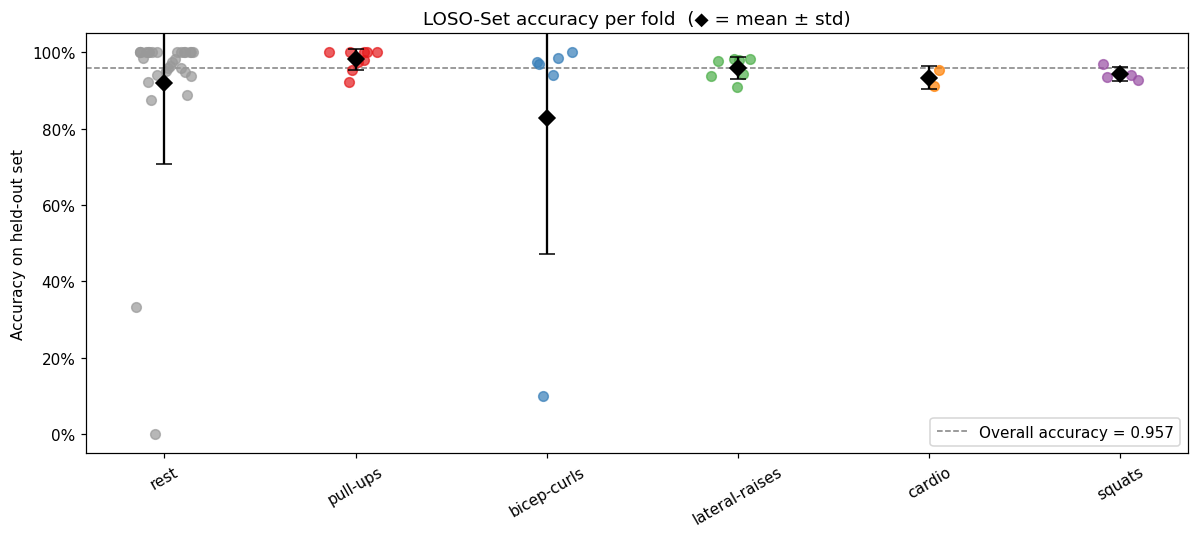

In [11]:
# ── Per-fold accuracy strip plot, grouped by activity ─────────────────────────
activities_ordered = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
act_positions = {act: i for i, act in enumerate(activities_ordered)}

fig, ax = plt.subplots(figsize=(11, 5))
for _, row in results_df.iterrows():
    x = act_positions[row["activity"]]
    color = LABEL_COLORS[row["label"]]
    ax.scatter(x + np.random.uniform(-0.15, 0.15), row["accuracy"],
               color=color, alpha=0.7, s=40, zorder=3)

# Overlay mean ± std per activity
for act in activities_ordered:
    sub = results_df[results_df["activity"] == act]
    if len(sub) == 0:
        continue
    x = act_positions[act]
    m, s = sub["accuracy"].mean(), sub["accuracy"].std()
    ax.errorbar(x, m, yerr=s, fmt="D", color="black",
                markersize=7, capsize=5, zorder=4, linewidth=1.5)

ax.set_xticks(range(len(activities_ordered)))
ax.set_xticklabels(activities_ordered, rotation=30)
ax.set_ylabel("Accuracy on held-out set")
ax.set_title("LOSO-Set accuracy per fold  (◆ = mean ± std)")
ax.set_ylim(-0.05, 1.05)
ax.axhline(overall_acc, color="grey", linestyle="--", linewidth=1,
           label=f"Overall accuracy = {overall_acc:.3f}")
ax.legend()
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

---
## Step 7 — Aggregate Evaluation

### Confusion matrix

The confusion matrix pools predictions across all 58 LOSO-Set folds, giving one unified view of how the model performs across the full dataset. Each cell $(i, j)$ shows how many windows whose true label is $i$ were predicted as $j$. A good model concentrates values on the diagonal; off-diagonal cells reveal which pairs of activities are most easily confused.

### Classification report

Precision, recall, and F1-score are reported per class:

- **Precision** — of all windows predicted as class $c$, what fraction actually belong to $c$? High precision means few false positives.
- **Recall** — of all windows that truly belong to class $c$, what fraction were correctly identified? High recall means few false negatives.
- **F1-score** — the harmonic mean of precision and recall; a balanced single-number summary of per-class performance.

Two aggregate F1-scores are reported:
- **Macro F1** — unweighted mean across classes; treats every class equally regardless of size. This is the primary metric for this project because all activity classes are equally important.
- **Weighted F1** — mean weighted by class frequency; dominated by the larger rest class.

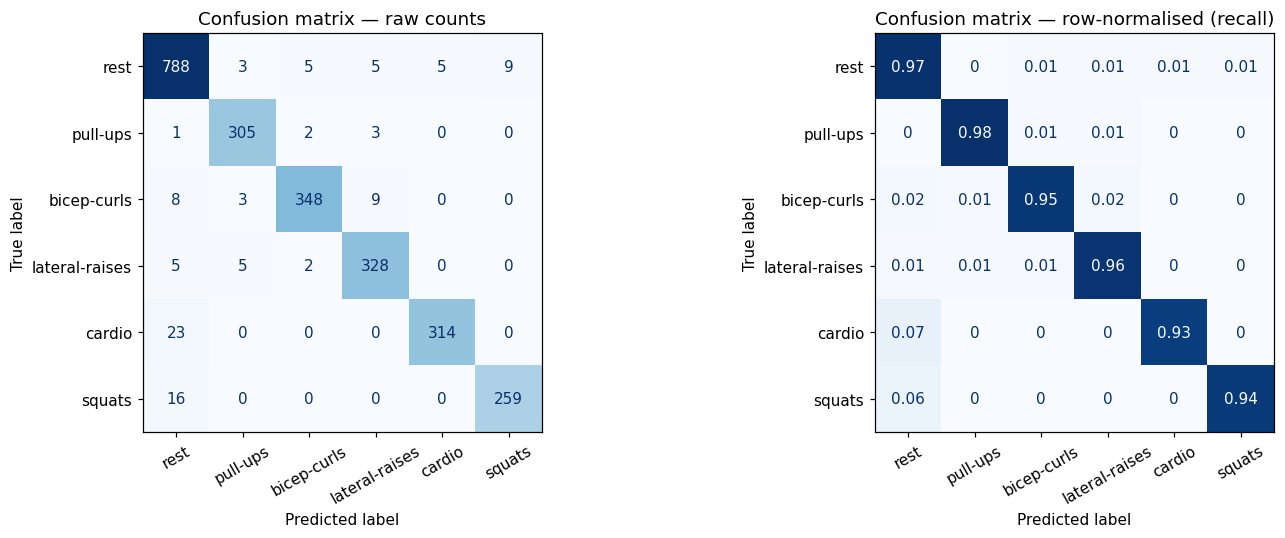

Classification report (pooled LOSO-Set predictions):

                precision    recall  f1-score   support

          rest       0.94      0.97      0.95       815
      pull-ups       0.97      0.98      0.97       311
   bicep-curls       0.97      0.95      0.96       368
lateral-raises       0.95      0.96      0.96       340
        cardio       0.98      0.93      0.96       337
        squats       0.97      0.94      0.95       275

      accuracy                           0.96      2446
     macro avg       0.96      0.96      0.96      2446
  weighted avg       0.96      0.96      0.96      2446



In [12]:
class_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

# ── Normalised confusion matrix ────────────────────────────────────────────────
cm      = confusion_matrix(all_y_true, all_y_pred, labels=sorted(LABEL_MAP))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp_raw = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp_raw.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix — raw counts")
axes[0].tick_params(axis="x", rotation=30)

# Row-normalised (recall per class on diagonal)
disp_norm = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion matrix — row-normalised (recall)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# ── Classification report ──────────────────────────────────────────────────────
print("Classification report (pooled LOSO-Set predictions):\n")
print(classification_report(all_y_true, all_y_pred,
                             labels=sorted(LABEL_MAP),
                             target_names=class_names,
                             zero_division=0))

---
## Step 8 — Feature Importance Analysis

### What XGBoost feature importance measures

XGBoost tracks how much each feature contributed to reducing the model's loss across all trees. We use **gain** as the importance metric — the average improvement in loss brought by splits on that feature, averaged across all trees in which it appears. Gain is generally more informative than frequency-based importance (which simply counts how often a feature is used as a split point) because it directly reflects how much each feature reduces prediction error.

Importance is computed from a single model trained on **all available data** (no held-out fold), which gives the most stable estimate of feature relevance. The top features reveal which signal channels and which types of descriptors (temporal, statistical, or spectral) carry the most discriminative information for distinguishing the six activity classes.

Understanding which features matter most has practical value for future work: if, say, spectral features on the gyroscope magnitude dominate, it suggests that the model is primarily leveraging the frequency signature of wrist rotation — which in turn may inform decisions about sensor placement, sampling rate, or data augmentation strategies.

In [13]:
# Train one model on all data for stable feature importance estimation.
# Use 300 trees for the final model — more than the CV loop uses.
sw_all = compute_sample_weight("balanced", y)
final_model = make_model(n_estimators=300)
final_model.fit(X, y, sample_weight=sw_all)

importance_scores = final_model.get_booster().get_score(importance_type="gain")
importance_df = (pd.DataFrame(
                    {"feature": list(importance_scores.keys()),
                     "gain":    list(importance_scores.values())})
                 .sort_values("gain", ascending=False)
                 .reset_index(drop=True))

# Map f0, f1, ... back to actual feature names
importance_df["feature_name"] = importance_df["feature"].apply(
    lambda f: FEATURE_COLS[int(f[1:])] if f.startswith("f") else f
)

print(f"Features with non-zero importance: {len(importance_df)} / {len(FEATURE_COLS)}")
print(f"\nTop 20 features by gain:")
display(importance_df[["feature_name", "gain"]].head(20))

Features with non-zero importance: 962 / 1270

Top 20 features by gain:


,feature_name,gain
0,gyr_y_Mean absolute deviation,170.014999
1,gyr_z_Absolute energy,168.415817
2,gyr_y_Area under the curve,105.185188
3,acc_z_Spectral slope,99.708374
4,accel_mag_Fundamental frequency,87.626411
5,gyr_y_Root mean square,76.586540
6,gyr_z_Power bandwidth,75.082977
7,gyr_z_Spectral distance,74.258522
8,acc_x_Zero crossing rate,73.170738
9,acc_x_Mean absolute diff,67.242844


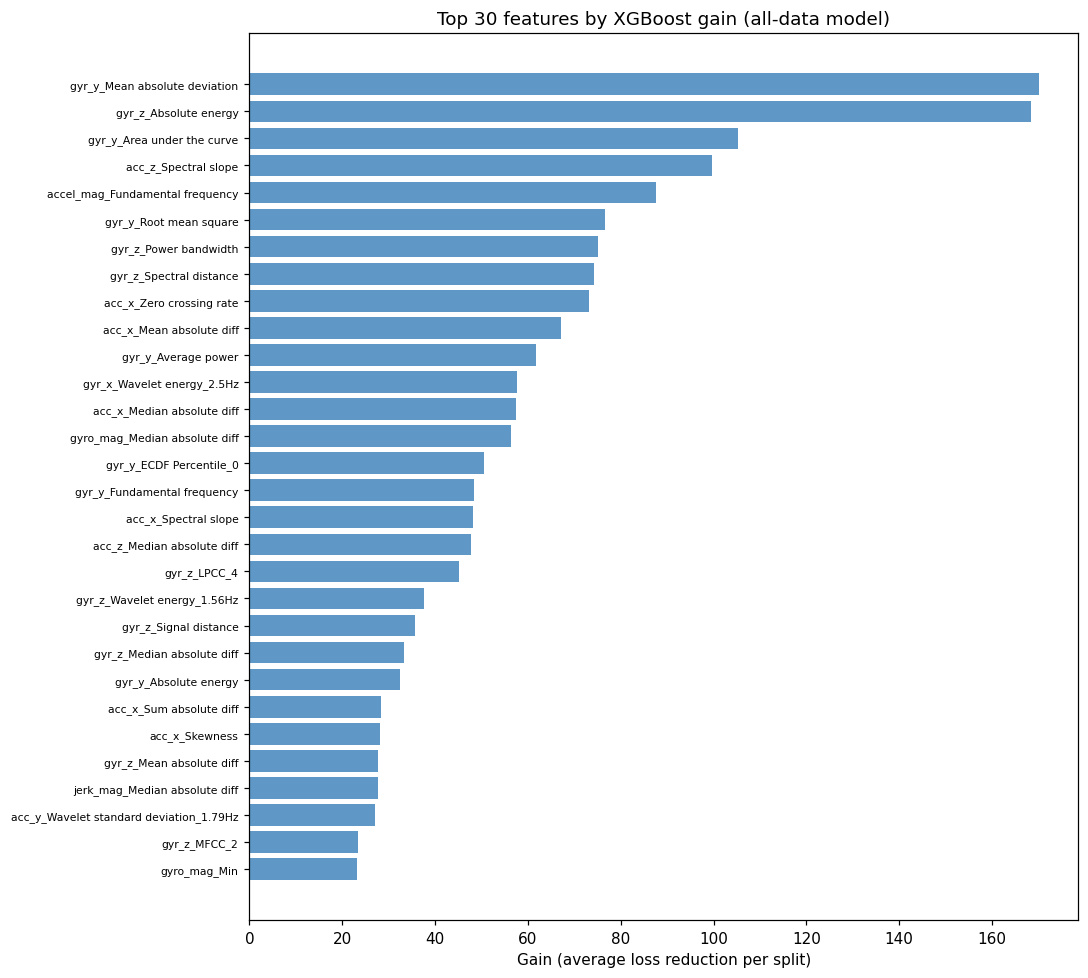

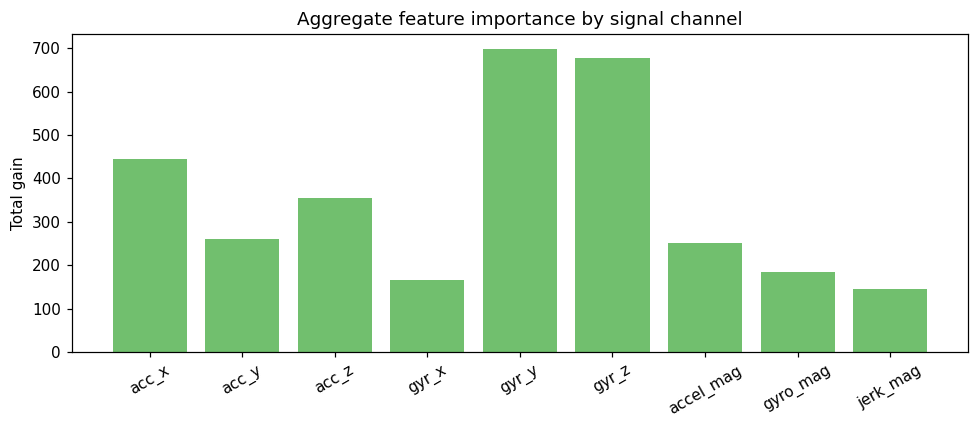

In [14]:
# ── Top-30 features bar chart ─────────────────────────────────────────────────
top_n = 30
top_feats = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(top_n), top_feats["gain"].values, color="#377eb8", alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([n[:65] for n in top_feats["feature_name"]], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Gain (average loss reduction per split)")
ax.set_title(f"Top {top_n} features by XGBoost gain (all-data model)")
plt.tight_layout()
plt.show()

# ── Gain by signal channel ────────────────────────────────────────────────────
channel_order = ["acc_x", "acc_y", "acc_z",
                 "gyr_x", "gyr_y", "gyr_z",
                 "accel_mag", "gyro_mag", "jerk_mag"]

def channel_from_name(fname):
    for ch in channel_order:
        if fname.startswith(ch + "_"):
            return ch
    return "other"

importance_df["channel"] = importance_df["feature_name"].apply(channel_from_name)
by_channel = (importance_df.groupby("channel")["gain"].sum()
              .reindex(channel_order, fill_value=0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_channel.index, by_channel.values, color="#4daf4a", alpha=0.8)
ax.set_ylabel("Total gain")
ax.set_title("Aggregate feature importance by signal channel")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

---
## Step 9 — Final Model: Train on All Data and Save

### Why train a final model on all data?

The LOSO-Set cross-validation procedure is used exclusively for **evaluation** — estimating how well the model generalises to unseen exercise sets. The CV models themselves (one per fold) are discarded after their test predictions are collected, because each was trained on only a subset of the available data.

For **deployment** — i.e., the model that would actually be run on new Apple Watch recordings — we train a single final model on the entire dataset. This model benefits from all 2,446 windows and all 58 sets, giving it the most comprehensive view of the signal space. Its expected real-world performance is estimated by the aggregate CV metrics computed above.

The model is saved in two formats:
- **`models/xgboost_baseline.json`** — XGBoost's native format; portable, human-inspectable, and loadable without joblib
- **`models/xgboost_baseline.joblib`** — Python-native format; convenient for scikit-learn pipelines

In [15]:
os.makedirs("models", exist_ok=True)

# final_model is already trained on all data from the importance step above
final_model.save_model("models/xgboost_baseline.json")
joblib.dump(final_model, "models/xgboost_baseline.joblib")

print("Final model saved:")
print(f"  models/xgboost_baseline.json    "
      f"({os.path.getsize('models/xgboost_baseline.json')/1024:.0f} KB)")
print(f"  models/xgboost_baseline.joblib  "
      f"({os.path.getsize('models/xgboost_baseline.joblib')/1024:.0f} KB)")

print(f"\n{'='*55}")
print(f"  LOSO-Set CV summary")
print(f"{'='*55}")
print(f"  Overall accuracy  : {overall_acc:.4f}  ({overall_acc*100:.1f} %)")
print(f"  Macro F1-score    : {overall_f1:.4f}")
print(f"  Folds (sets)      : {n_folds}")
print(f"  Training windows  : {len(y):,}")
print(f"  Features          : {len(FEATURE_COLS):,}")
print(f"{'='*55}")

Final model saved:
  models/xgboost_baseline.json    (1413 KB)
  models/xgboost_baseline.joblib  (1596 KB)

  LOSO-Set CV summary
  Overall accuracy  : 0.9575  (95.7 %)
  Macro F1-score    : 0.9589
  Folds (sets)      : 58
  Training windows  : 2,446
  Features          : 1,270
